In [ ]:
# Import required libraries
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(23)


# --------------------------------------------------------
# Generate samples for Class 1
# --------------------------------------------------------

# Mean vector for Class 1
mu_vec1 = np.array([0, 0, 0])

# Identity covariance matrix (features are independent with variance = 1)
cov_mat1 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

# Generate 20 samples from a multivariate normal distribution
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

# Create a DataFrame and assign class label = 1
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1


# --------------------------------------------------------
# Generate samples for Class 2
# --------------------------------------------------------

# Mean vector for Class 2
mu_vec2 = np.array([1, 1, 1])

# Identity covariance matrix
cov_mat2 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

# Generate 20 samples from another multivariate normal distribution
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

# Create a DataFrame and assign class label = 0
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0


# --------------------------------------------------------
# Combine both classes into a single dataset
# --------------------------------------------------------

# Concatenate the two DataFrames
df = pd.concat([df, df1], ignore_index=True)

# Shuffle the rows to mix samples from both classes
df = df.sample(40, random_state=23)

In [2]:
df.head()

,feature1,feature2,feature3,target
18,-0.331617,-1.632386,0.619114,1
23,1.010229,1.437830,2.327788,0
8,0.241106,-0.952510,-0.136267,1
22,1.676860,4.187503,-0.080565,0
33,2.823378,-0.332863,2.637391,0


In [ ]:
# Import Plotly Express for interactive visualizations
import plotly.express as px

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x=df['feature1'],          # Values for the x-axis
    y=df['feature2'],          # Values for the y-axis
    z=df['feature3'],          # Values for the z-axis
    color=df['target'].astype('str')   # Color points based on class labels
)

# Customize the appearance of the markers
fig.update_traces(
    marker=dict(
        size=12,                      # Marker size
        line=dict(
            width=2,                  # Border width
            color='DarkSlateGrey'     # Border color
        )
    ),
    selector=dict(mode='markers')     # Apply changes only to scatter markers
)

# Display the interactive 3D plot
fig.show()

In [5]:
# Step 1 - Apply Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [6]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
# Step 3 - Finding Eigen Values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

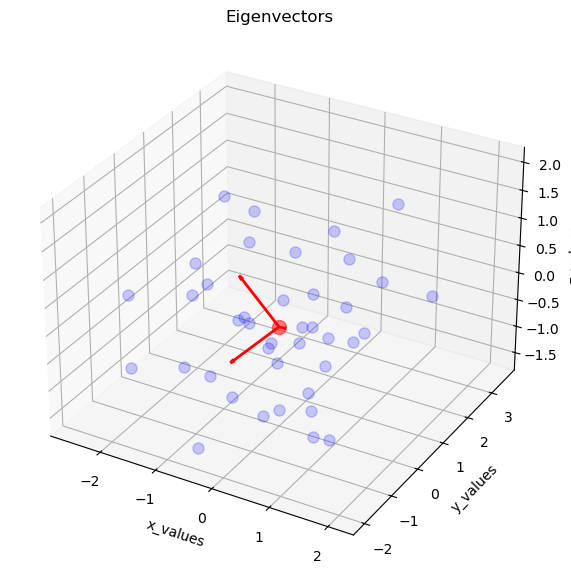

In [14]:
# Display matplotlib plots inside the Jupyter Notebook
%matplotlib inline

# Import required libraries
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a figure of size 7x7 inches
fig = plt.figure(figsize=(7, 7))

# Add a 3D subplot
ax = fig.add_subplot(111, projection='3d')

# ------------------------------------------
# Plot the original data points in 3D space
# ------------------------------------------
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)

# --------------------------------------------
# Plot the mean (centroid) of all data points
# --------------------------------------------
ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)

# ---------------------------------------------------
# Draw the eigenvectors starting from the mean point
# ---------------------------------------------------
for v in eigen_vectors.T:
    ax.quiver(
        [df['feature1'].mean()],
        [df['feature2'].mean()],
        [df['feature3'].mean()],
        [v[0]],
        [v[1]],
        [v[2]],
        color='red',
        linewidth=2,
        length=1.0,
        normalize=True,
        arrow_length_ratio=0.08
    )

# --------------------------------------------------------
# Label the axes
# --------------------------------------------------------
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

# Add plot title
plt.title('Eigenvectors')

# Display the plot
plt.show()

In [15]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [16]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)

new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.726114,0.492511,1
1,-0.220797,-1.441911,0
2,0.688605,0.658084,1
3,-3.367715,-0.254627,0
4,0.227326,-2.669841,0


In [ ]:
# Convert the target column to string so Plotly treats it as a categorical variable
new_df['target'] = new_df['target'].astype('str')

# Create a 2D scatter plot using the first two principal components
fig = px.scatter(
    x=new_df['PC1'],                          # First Principal Component (x-axis)
    y=new_df['PC2'],                          # Second Principal Component (y-axis)
    color=new_df['target'],                   # Color points based on class labels
    color_discrete_sequence=px.colors.qualitative.G10  # Set the color palette
)

# Customize the appearance of the scatter plot markers
fig.update_traces(
    marker=dict(
        size=12,                              # Marker size
        line=dict(
            width=2,                          # Marker border width
            color='DarkSlateGrey'             # Marker border color
        )
    ),
    selector=dict(mode='markers')             # Apply changes only to scatter markers
)

# Display the interactive scatter plot
fig.show()